# From Subhalos to Observed Satellites
## Part 1 — The halo catalog, occupation, and the SHMR

A CDM simulation gives us **dark-matter subhalos**. A survey gives us **galaxies**. Comparing
the two directly is the most common mistake in this field, so we spend the tutorial building
the chain that connects them, one link at a time.

```mermaid
flowchart LR
    A[CDM subhalo catalog] --> B[Galaxy occupation]
    B --> C[SHMR: assign M_star]
    C --> D[Assign size / luminosity]
    D --> E[Mock observing geometry]
    E --> F[Survey selection]
    F --> G[Mock observed satellites]
    G --> H[Compare with MW / ELVES / ELVES-Dwarf]
```

Written as conditional probabilities,

$$P(\mathrm{data}\mid\mathrm{DM}) \;=\; \underbrace{P(\mathrm{data}\mid\mathrm{galaxies})}_{\text{Part 2}}\;\underbrace{P(\mathrm{galaxies}\mid\mathrm{halos})}_{\textbf{this notebook}}\;\underbrace{P(\mathrm{halos}\mid\mathrm{DM})}_{\text{taken as input}}$$

The dark-matter model is fixed throughout; we never touch it.

This notebook covers the first two links:

| section | question | model |
|---|---|---|
| **0** | what is in the halo catalog? | — |
| **1** | does a subhalo host a galaxy? | $f_{\rm gal}(M_{\rm peak})$ |
| **2** | if so, how many stars? | $M_\star(M_{\rm peak})$ + scatter |

Everything runs off a pre-computed catalog, so you can read straight through in a few minutes
and then go back and turn knobs. Each section ends with a **Try it** exercise.

*Jiaxuan Li ([jiaxuanl@stanford.edu](mailto:jiaxuanl@stanford.edu)) — [github.com/elves-surveys/satellite_modeling_tutorial](https://github.com/elves-surveys/satellite_modeling_tutorial)*

> **This is a toy model, not a fit.** Every relation in this tutorial — the occupation
> fraction, the SHMR, the size–luminosity relation, the mass-to-light ratio — is a simple
> functional form with parameters fixed by hand, chosen to be transparent and fast rather than
> to be a state-of-the-art prediction. The dark-matter catalog itself has no disk and no bulge.
> The point is to make every step in the chain from subhalo to mock-observed satellite
> explicit and inspectable, not to produce a number you should quote.
>
> So do not take the counts, mass functions, or "agreement"/"tension" with real data at face
> value anywhere in this tutorial — including the comparisons to ELVES and the Milky Way census
> in Parts 3–4. Every discrepancy flagged along the way comes with a list of simplifications
> that could easily explain it before dark matter physics does. Treat the notebooks as a
> template for building your own, better model, not as a result in themselves.

---
## Setup

`src/` holds the model code, the plotting style, and the literature curves we compare
against. None of it depends on SatGen, so open any module when you want to see what a
function really does.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import io, galaxy_halo as gh, statistics as st, reference as ref, plotting as pl

pl.use_tutorial_style()
rng = np.random.default_rng(42)     # fixed seed -> everyone sees the same mock

### The catalog

The halos come from **SatGen**, a semi-analytic model of satellite evolution. It is much
cheaper than a zoom-in simulation, so we get many independent realizations at the same host
mass — which is exactly what we need in order to see host-to-host scatter.

One caveat to carry along: the host in these runs has no disk. Satellites therefore survive
closer to the centre than they would in reality, and the host-to-host scatter is probably a
little smaller than it should be.

In [2]:
hosts = io.load_hosts(data_dir='../data/', prefix='satgen_new_MW')
subs  = io.load_subhalos(data_dir='../data/', prefix='satgen_new_MW')
mpeak_min = 1e7        # SatGen's resolution limit for this run

print(f"{len(hosts):,} hosts, {len(subs):,} subhalos")
subs.head(3)

303 hosts, 2,333,215 subhalos


,host_id,host_lgmvir,host_mvir,host_rvir,host_lgmstar,host_m200c,host_r200c,sub_id,order,mpeak,...,x,y,z,r_3d,r_proj,r_over_rvir,rproj_over_rvir,r_over_r200c,rproj_over_r200c,is_orphan
0,300,11.5,3.162278e+11,176.402878,9.557754,2.752860e+11,134.194733,1,1,1.399469e+07,...,-100.386749,-88.023819,53.937664,143.996399,133.512894,0.816293,0.756863,1.073041,0.994919,False
1,300,11.5,3.162278e+11,176.402878,9.557754,2.752860e+11,134.194733,2,1,2.242069e+07,...,6.407572,-122.947556,116.464508,169.473129,123.114410,0.960716,0.697916,1.262890,0.917431,False
2,300,11.5,3.162278e+11,176.402878,9.557754,2.752860e+11,134.194733,3,1,1.085486e+08,...,23.071457,-123.084312,-5.499566,125.348656,125.227951,0.710582,0.709897,0.934080,0.933181,False


The columns fall into three groups:

| group | columns | meaning |
|---|---|---|
| **host** | `host_id`, `host_lgmvir`, `host_mvir`, `host_rvir`, `host_lgmstar` | which host this subhalo belongs to |
| **halo properties** | `mpeak`, `vpeak`, `macc`, `z_acc`, `rvir_acc`, `mass_now`, `vmax_now` | the dark-matter quantities |
| **position** | `x`, `y`, `z`, `r_3d`, `r_proj`, `r_over_rvir` | present-day, host-centric, in kpc |

Plus one bookkeeping flag, `is_orphan`: subhalos stripped below SatGen's mass floor whose
orbits are still being integrated. We keep them — `prep/README.md` explains why at length.
The next cell prints what fraction of the sample they are, and it is a large fraction.

In [3]:
# What host masses does this catalog cover?
lgm = hosts["host_lgmvir"]
print(f"{len(hosts)} host realizations, log Mvir = {lgm.min():.2f} - {lgm.max():.2f}, "
      f"{lgm.nunique()} masses on the grid, {len(hosts) // lgm.nunique()} realizations each")

# The host-mass bin we will use throughout: Milky-Way-like.
LGM_MW = 12.0    # ~Milky Way
BINW = 0.1
sats_mw, hid_mw = io.host_bin(subs, hosts, LGM_MW, width=BINW,
                              mpeak_min=mpeak_min, aperture="r_3d")

print(f"\nMW-like bin, log Mvir = {LGM_MW} +/- {BINW}: {len(hid_mw)} hosts, "
      f"{len(sats_mw):,} subhalos above Mpeak = {mpeak_min:.0e}, "
      f"{100 * sats_mw.is_orphan.mean():.0f}% orphans")

303 host realizations, log Mvir = 11.50 - 12.50, 101 masses on the grid, 3 realizations each

MW-like bin, log Mvir = 12.0 +/- 0.1: 63 hosts, 278,886 subhalos above Mpeak = 1e+07, 82% orphans


---
# Section 0 — The raw subhalo population

Before adding any galaxy physics, look at what we start from.

The standard summary statistic is the cumulative subhalo mass function,

$$N_{\rm sub}(>M_{\rm peak}),$$

the number of subhalos per host above a given peak mass, inside some aperture. The choice of
mass matters: we count on $M_{\rm peak}$, the largest mass the subhalo ever had, rather than
on its present-day mass. A galaxy sits deep inside its halo, so stripping 99% of the dark
matter does not remove the stars.

The next cell counts, for every host, how many subhalos lie above each of 40 mass thresholds.
Then we plot that two ways: five individual hosts, and all of them at once.

In [4]:
edges = np.logspace(7.0, 10.5, 40)      # the Mpeak thresholds we count above
counts_mw  = st.per_host_counts(sats_mw, edges, "mpeak", host_ids=hid_mw)
print("shape (n_host, n_edge):", counts_mw.shape)

shape (n_host, n_edge): (63, 40)


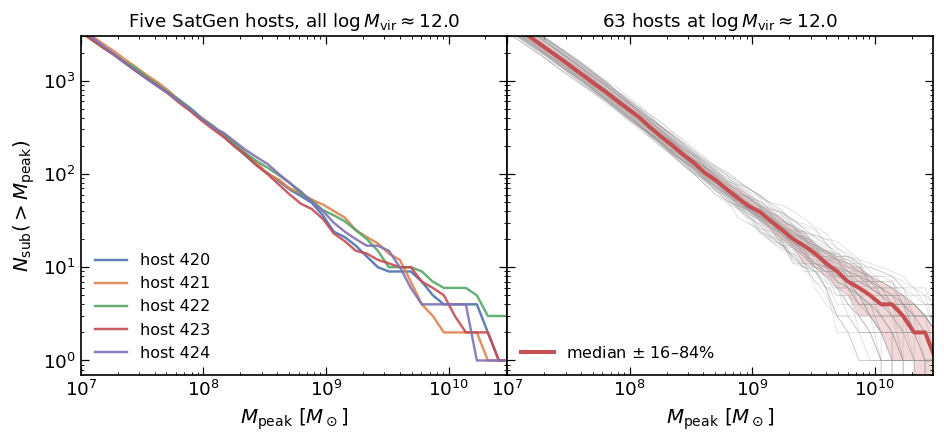

In [5]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# five individual hosts, all with the same host mass
for i, hid in enumerate(hid_mw[:5]):
    one = sats_mw[sats_mw.host_id == hid]
    ax1.plot(edges, st.cumulative_counts(one.mpeak, edges),
            color=pl.HOST_COLORS[i], lw=1.6, alpha=0.9, label=f"host {hid}")

ax1.set(xscale="log", yscale="log", xlim=(mpeak_min, 3e10), ylim=(0.7, 3e3),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"$N_{\rm sub}(>M_{\rm peak})$")
ax1.set_title(rf"Five SatGen hosts, all $\log M_{{\rm vir}} \approx {LGM_MW}$", fontsize=12)
ax1.legend(loc="lower left")


# Plot all hosts
for row in counts_mw:
    ax2.plot(edges, row, color="0.6", lw=0.5, alpha=0.35)
pl.plot_band(ax2, edges, counts_mw, color="#C44E52", lw=2.6,
             label=r"median $\pm$ 16–84%")
ax2.set(xscale="log", yscale="log", xlim=(mpeak_min, 3e10), ylim=(0.7, 3e3),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$")
ax2.set_title(rf"{len(hid_mw)} hosts at $\log M_{{\rm vir}} \approx {LGM_MW}$", fontsize=12)
ax2.legend(loc="lower left")

plt.subplots_adjust(wspace=0)

> ### Key lesson — Section 0
>
> The catalog contains **dark-matter substructure, not galaxies**. A Milky-Way-mass host has
> hundreds of subhalos above $10^8 M_\odot$; the Milky Way has ~60 known satellites. Most of
> these subhalos cannot be hosting a galaxy we can see.
>
> And $N_{\rm sub}(>M_{\rm peak})$ is a **distribution over hosts**, not a number. The Milky
> Way, like any other individual host, is one draw from it.

**Try it.** The `io.host_bin` call above used `aperture="r_3d"`. Switch it to `"r_proj"` and
re-run this far: more subhalos, or fewer? You should get about 7% more, because a cut on
projected radius selects a cylinder rather than a sphere. That is the aperture you are stuck
with once the host is extragalactic.

---
# Section 1 — Galaxy occupation

Low-mass halos struggle to form stars. The UV background at reionization heats the gas so it
can no longer cool into a shallow potential well, and supernova feedback ejects what is left.
Below some halo mass the halo simply stays dark.

We model that as a smooth step in $\log M_{\rm peak}$:

$$f_{\rm gal}(M_{\rm peak}) = \frac{1}{2}\left[1 + \operatorname{erf}\left(\frac{\log_{10} M_{\rm peak} - \log_{10} M_{50}}{\sqrt{2}\,\sigma_{\rm gal}}\right)\right]$$

- $M_{50}$ — the halo mass at which **half** of all halos light up;
- $\sigma_{\rm gal}$ — the **width** of the transition, in dex ($\sigma_{\rm gal}\to 0$ is a
  hard threshold).

For each subhalo we then draw $u \sim \mathcal{U}(0,1)$ and call it luminous if
$u < f_{\rm gal}$.

### 1.1 How well do we know the two parameters?

Not very. For orientation:

| source | $\log M_{50}$ | $\sigma_{\rm gal}$ | how it was obtained |
|---|---|---|---|
| Nadler et al. (2020) | $7.5$ | $0.4$ | fit to the MW satellites (DES + PS1), forward-modelled through the survey selection |
| Dooley et al. (2016) | $8.75$ | $0.33$ | *predicted*, not fit: the Barber+14 reionization model |
| **this tutorial** | $8.0$ | $0.4$ | fixed by hand |

A factor of ~20 in $M_{50}$ separates a fit to data from a physical prediction. We sit between
the two at $(\log M_{50}, \sigma_{\rm gal}) = (8.0, 0.4)$ and treat it as a knob, not a
measurement. The figure shows what each parameter does on its own.

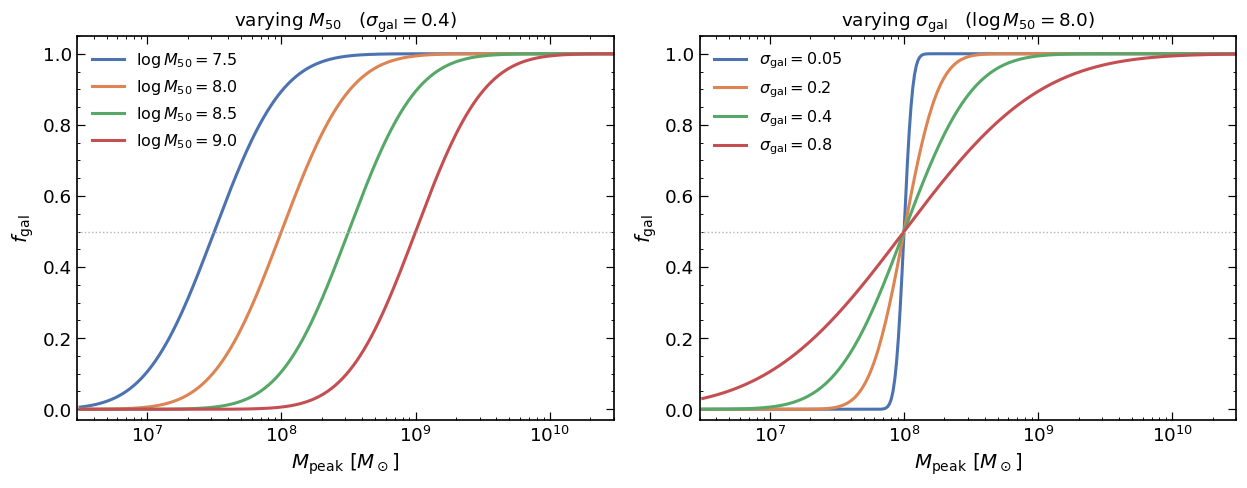

In [6]:
mgrid = np.logspace(6.5, 10.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# --- vary M50 at fixed width
ax = axes[0]
for c, lgM50 in zip(pl.HOST_COLORS, [7.5, 8.0, 8.5, 9.0]):
    ax.plot(mgrid, gh.occupation_fraction(mgrid, lgM50, 0.4), color=c,
            label=rf"$\log M_{{50}}={lgM50}$")
ax.set_title(r"varying $M_{50}$   ($\sigma_{\rm gal}=0.4$)", fontsize=12)

# --- vary width at fixed M50
ax = axes[1]
for c, sg in zip(pl.HOST_COLORS, [0.05, 0.2, 0.4, 0.8]):
    ax.plot(mgrid, gh.occupation_fraction(mgrid, 8.0, sg), color=c,
            label=rf"$\sigma_{{\rm gal}}={sg}$")
ax.set_title(r"varying $\sigma_{\rm gal}$   ($\log M_{50}=8.0$)", fontsize=12)

for ax in axes:
    ax.set(xscale="log", xlim=(3e6, 3e10), ylim=(-0.03, 1.05),
           xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"$f_{\rm gal}$")
    ax.axhline(0.5, color="0.7", lw=0.9, ls=":")
    ax.legend(loc="upper left")
fig.tight_layout()

### 1.2 Apply it to the subhalos

One Bernoulli draw per subhalo, which adds an `is_luminous` column. Two caveats before quoting
any number that comes out of it:

- the catalog stops at $M_{\rm peak} = 10^7 M_\odot$, SatGen's resolution limit and not a
  physical edge. "Satellites per host" is never a number on its own; it always comes with the
  mass you stopped counting at.
- $M_{50} = 10^8 M_\odot$ sits only one decade above that limit, so a good fraction of the
  halos near the floor still light up and the luminous count is not fully converged either.

The second cell checks that the mock reproduces the input curve. It tests our code, not any
physics.

In [7]:
occ = gh.FIDUCIAL_OCCUPATION
sats_mw = sats_mw.copy()
sats_mw["is_luminous"] = gh.assign_occupation(sats_mw.mpeak, rng=rng, **occ)

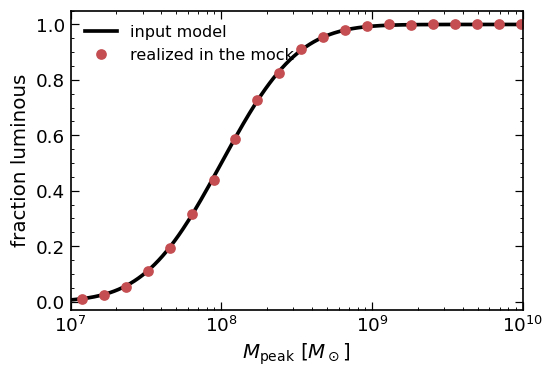

In [8]:
# sanity check: does the realized fraction reproduce the input curve?
bins = np.logspace(7, 10.5, 25)
idx  = np.digitize(sats_mw.mpeak, bins)
ctr  = np.sqrt(bins[1:] * bins[:-1])
frac = np.array([sats_mw.is_luminous.values[idx == i + 1].mean()
                 if (idx == i + 1).sum() > 20 else np.nan for i in range(len(ctr))])

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(mgrid, gh.occupation_fraction(mgrid, **occ), color="k", lw=2.4, label="input model")
ax.plot(ctr, frac, "o", color="#C44E52", ms=6, label="realized in the mock")
ax.set(xscale="log", xlim=(1e7, 1e10), ylim=(-0.03, 1.05),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"fraction luminous")
ax.legend(loc="upper left"); fig.tight_layout()

### 1.3 What occupation does to the mass function

Left: the same hosts with and without the occupation cut. Right: what happens as $M_{50}$
slides across half a decade at a time. Watch where the coloured curves peel away from the grey
band — and where they don't.

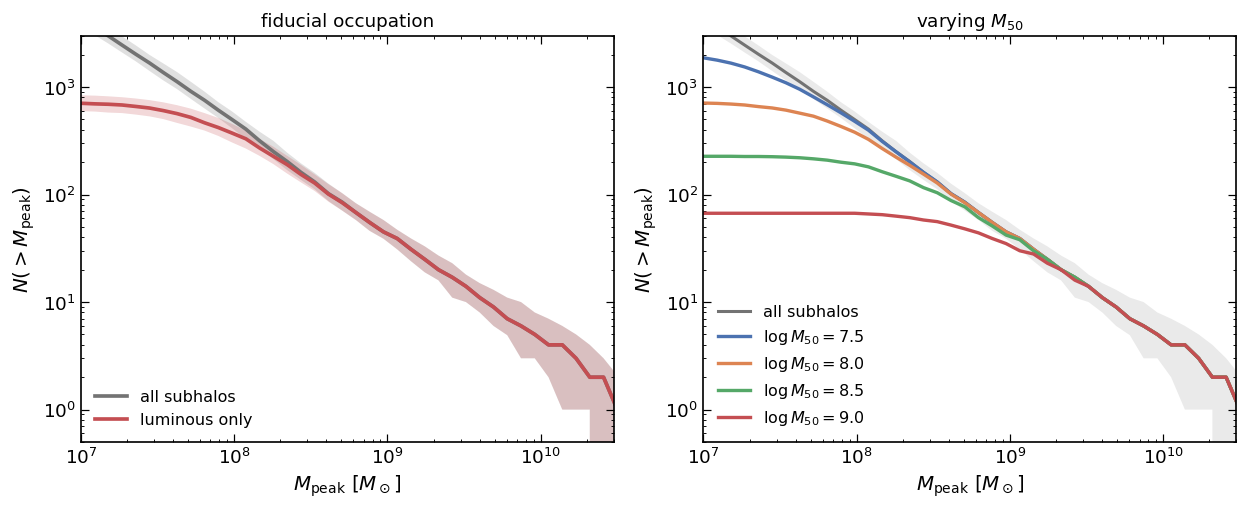

In [9]:
lum_mw = sats_mw[sats_mw.is_luminous]
counts_lum = st.per_host_counts(lum_mw, edges, "mpeak", host_ids=hid_mw)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

ax = axes[0]
pl.plot_band(ax, edges, counts_mw,  color="0.45",    lw=2.4, label="all subhalos")
pl.plot_band(ax, edges, counts_lum, color="#C44E52", lw=2.4, label="luminous only")
ax.set(xscale="log", yscale="log", xlim=(1e7, 3e10), ylim=(0.5, 3e3),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"$N(>M_{\rm peak})$")
ax.legend(loc="lower left"); ax.set_title("fiducial occupation", fontsize=12)

# --- how much does M50 matter?
ax = axes[1]
pl.plot_band(ax, edges, counts_mw, color="0.45", lw=2.0, label="all subhalos", alpha=0.15)
for c, lgM50 in zip(pl.HOST_COLORS, [7.5, 8.0, 8.5, 9.0]):
    lum = sats_mw[gh.assign_occupation(sats_mw.mpeak, lgM50, 0.4, rng=rng)]
    cnt = st.per_host_counts(lum, edges, "mpeak", host_ids=hid_mw)
    ax.plot(edges, np.median(cnt, axis=0), color=c, lw=2.2, label=rf"$\log M_{{50}}={lgM50}$")
ax.set(xscale="log", yscale="log", xlim=(1e7, 3e10), ylim=(0.5, 3e3),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"$N(>M_{\rm peak})$")
ax.legend(loc="lower left"); ax.set_title(r"varying $M_{50}$", fontsize=12)
fig.tight_layout()

> ### Key lesson — Section 1
>
> **Occupation and the SHMR are separate pieces of the model.** Occupation is
> $P(\mathrm{galaxy}\mid M_{\rm peak})$, a yes/no question. It says nothing about how bright
> the galaxy is once it exists.
>
> It is also almost purely a faint-end effect. Constraining it takes ultra-faint dwarfs, so
> ELVES and SAGA are not deep enough to help.

**Try it.** Set `occ = dict(gh.FIDUCIAL_OCCUPATION, logM50=7.5)` in Section 1.2 and re-run
from there.

---
# Section 2 — The stellar-to-halo mass relation (SHMR)

What we want is the full conditional distribution

$$P(M_\star \mid M_{\rm peak}, \mathrm{galaxy}).$$

A real galaxy's stellar mass is not a function of $M_{\rm peak}$ (or $V_{\rm peak}$) alone. It
is set by the halo's assembly history: when it formed, when it fell in, how long it kept its
gas. That is why semi-analytic models (e.g. GRUMPY, Manwadkar & Kravtsov 2022) and
hydrodynamic simulations build $M_\star$ from a mass-accretion history and an integrated
star-formation history. Two halos with the same $M_{\rm peak}$ but different formation times
end up with different $M_\star$, and different $M_V$.

For this tutorial we throw that away and assume a power law in $M_{\rm peak}$ with lognormal
scatter:

$$\log_{10} M_\star = \log_{10}M_{\star,0} + \alpha\,\log_{10}\!\left(\frac{M_{\rm peak}}{M_0}\right) + \epsilon,
\qquad \epsilon \sim \mathcal{N}(0,\sigma_{\log M_\star}).$$

- $\alpha$ — the **slope**. Steeper means low-mass halos are disproportionately faint.
- $\sigma_{\log M_\star}$ — the **scatter**, in dex.

The scatter is where the assembly history we just discarded has gone: it stands in for
everything about a galaxy that $M_{\rm peak}$ alone cannot tell us. Both parameters live in
`gh.FIDUCIAL_SHMR`, and Section 2.3 is where we turn them.

Common variants, if you want to swap one in later — several are implemented in the main
ELVES-Dwarf repo, in `script/shmr.py`:

| variant | where |
|---|---|
| double power law | Behroozi+19 (their Eq. J1–J2), used with $\alpha=2.10$ by Danieli+23; Garrison-Kimmel+14, +17 |
| growing scatter | Garrison-Kimmel+17, $\sigma = 0.2 + \nu\,(\log M_{\rm peak} - 11.5)$ |
| occupation $f_{\rm gal}$ folded in | Manwadkar & Kravtsov 2022 (GRUMPY) |
| steeper single power law | Brook+14 |

### 2.1 Three published relations

Behroozi+19 is an empirical model of the whole galaxy population; Danieli+23 is fit to the
ELVES satellite abundances; Nadler+20 to the Milky Way satellites.

Over the dwarf range all three are close to power laws, with slopes within 10% of each other,
which is what licenses the simple model we are about to use. They part company on the scatter:
Behroozi+19 carry 0.2 dex down from massive centrals, Danieli+23 infer 0.06 dex from the ELVES
abundances. Where a paper does not constrain the scatter at dwarf masses it is assuming one,
and it is worth checking which.

Notice also where each curve stops being a measurement. Behroozi+19 is calibrated by stellar
mass functions and clustering down to $M_{\rm peak}\sim10^{10.5}$ (dotted line); everything to
the left is the fitted form extrapolated.

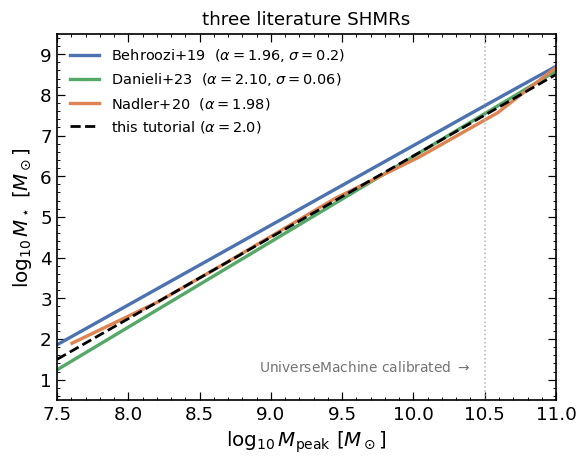

In [10]:
lgm_lit = np.linspace(7.5, 11.0, 300)
m_lit = 10 ** lgm_lit

a_b19 = ref.BEHROOZI19_PARAMS["alpha"]
a_d23 = ref.SHMR_POWERLAW_FITS["Danieli+23"]["alpha"]
a_n20 = ref.SHMR_POWERLAW_FITS["Nadler+20"]["alpha"]

curves = [
    (rf"Behroozi+19  ($\alpha={a_b19:.2f}$, $\sigma={ref.SHMR_SCATTER['Behroozi+19']}$)",
     ref.behroozi19_shmr(m_lit), pl.HOST_COLORS[0]),
    (rf"Danieli+23  ($\alpha={a_d23:.2f}$, $\sigma={ref.SHMR_SCATTER['Danieli+23']}$)",
     ref.danieli23_shmr(m_lit), pl.HOST_COLORS[2]),
    (rf"Nadler+20  ($\alpha={a_n20:.2f}$)",
     ref.nadler20_shmr(m_lit), pl.HOST_COLORS[1]),
]
fid = gh.mean_stellar_mass(m_lit, **{k: v for k, v in gh.FIDUCIAL_SHMR.items()
                                     if k != "sigma_logMstar"})

fig, ax = plt.subplots(figsize=(5.5, 4.4))

for lbl, y, c in curves:
    ax.plot(lgm_lit, y, color=c, lw=2.2, label=lbl)
n20, n20_s = ref.nadler20_shmr(m_lit), ref.nadler20_shmr(m_lit, scatter=True)
# ax.fill_between(lgm_lit, n20 - n20_s, n20 + n20_s, color=pl.HOST_COLORS[1], alpha=0.16, lw=0)
ax.plot(lgm_lit, fid, color="k", ls="--", lw=1.8,
        label=rf"this tutorial ($\alpha={gh.FIDUCIAL_SHMR['alpha']}$)")
ax.axvline(ref.BEHROOZI19_CALIBRATED_ABOVE, color="0.7", ls=":", lw=1.0)
ax.text(ref.BEHROOZI19_CALIBRATED_ABOVE - 0.1, 1.2, "UniverseMachine calibrated $\\rightarrow$",
        color="0.45", fontsize=9, ha="right")
ax.set(xlim=(7.5, 11.0), ylim=(0.5, 9.5),
       xlabel=r"$\log_{10} M_{\rm peak}\ [M_\odot]$",
       ylabel=r"$\log_{10} M_\star\ [M_\odot]$")
ax.set_title("three literature SHMRs", fontsize=12)
ax.legend(loc="upper left", fontsize=9.5)

fig.tight_layout()

### 2.2 Populating the halos

`populate_subhalos` does the occupation draw and the SHMR draw in one call and hands back only
the luminous satellites. Left: the mock in the $M_\star$–$M_{\rm peak}$ plane with the input
relation drawn over it, so you can see the scatter we put in. Right: the satellite stellar mass
function that comes out, one faint grey line per host.

In [11]:
mock = gh.populate_subhalos(
    sats_mw,
    occupation_params=gh.FIDUCIAL_OCCUPATION,
    shmr_params=gh.FIDUCIAL_SHMR,
    rng=np.random.default_rng(42),
)

print(f"{len(mock):,} luminous satellites  ({len(mock)/len(hid_mw):.0f} per host)")
mock[["host_id", "mpeak", "f_gal", "is_luminous", "logmstar", "r_3d"]].head(4)

45,155 luminous satellites  (717 per host)


,host_id,mpeak,f_gal,is_luminous,logmstar,r_3d
377611,420,7.973286e+08,0.987905,True,4.046355,219.036453
377612,420,9.010054e+08,0.991503,True,4.685198,215.126221
377617,420,7.951003e+08,0.987809,True,4.481266,191.436615
377621,420,6.438039e+07,0.316284,True,2.201099,195.898865


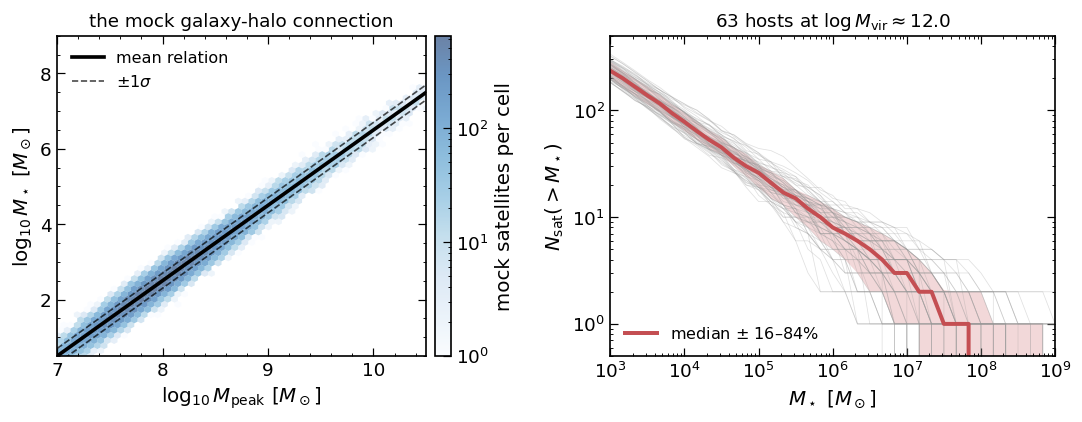

In [12]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
hb = ax.hexbin(np.log10(mock.mpeak), mock.logmstar, gridsize=55, bins="log",
               extent=(7, 10.5, 0.5, 9.0), cmap="Blues", mincnt=1, linewidths=0, alpha=0.6)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("mock satellites per cell")

lgm_line = np.linspace(7, 10.5, 100)
shmr_mean = {k: v for k, v in gh.FIDUCIAL_SHMR.items() if k != "sigma_logMstar"}
mu = gh.mean_stellar_mass(10**lgm_line, **shmr_mean)
ax.plot(lgm_line, mu, color="k", lw=2.4, label="mean relation")
for sgn in (+1, -1):
    ax.plot(lgm_line, mu + sgn * gh.FIDUCIAL_SHMR["sigma_logMstar"],
            color="k", lw=1.1, ls="--", alpha=0.7,
            label=r"$\pm 1\sigma$" if sgn > 0 else None)

ax.set(xlim=(7, 10.5), ylim=(0.5, 9.0),
       xlabel=r"$\log_{10} M_{\rm peak}\ [M_\odot]$",
       ylabel=r"$\log_{10} M_\star\ [M_\odot]$")
ax.set_title("the mock galaxy-halo connection", fontsize=12)
ax.legend(loc="upper left")

ax = axes[1]
ms_edges = np.logspace(3, 9.5, 40)
counts_ms = st.per_host_counts(mock, ms_edges, "mstar", host_ids=hid_mw)
for row in counts_ms:
    ax.plot(ms_edges, row, color="0.6", lw=0.5, alpha=0.3)
pl.plot_band(ax, ms_edges, counts_ms, color="#C44E52", lw=2.6,
             label=r"median $\pm$ 16–84%")

ax.set(xscale="log", yscale="log", xlim=(1e3, 1e9), ylim=(0.5, 5e2),
       xlabel=r"$M_\star\ [M_\odot]$", ylabel=r"$N_{\rm sat}(>M_\star)$")
ax.set_title(rf"{len(hid_mw)} hosts at $\log M_{{\rm vir}}\approx{LGM_MW}$", fontsize=12)
ax.legend(loc="lower left"); fig.tight_layout()

### 2.3 The two knobs: slope and scatter

The pivot is fixed at $10^{10}M_\odot$, so changing $\alpha$ rotates the relation about that
point: the bright end barely moves and the faint end swings.

The scatter is less intuitive. Changing $\sigma_{\log M_\star}$ does nothing to the mean
relation, so it looks like it should wash out. It doesn't. The subhalo mass function is steep,
so at fixed $M_\star$ more halos scatter **up** into a bin than scatter down out of it, and the
satellite population comes out more abundant at every mass. This is **Eddington bias**, and the
size of the boost is predictable:

$$\frac{N_\sigma}{N_0} \;\simeq\; \exp\!\left[\tfrac{1}{2}\left(\ln 10 \cdot \beta \cdot \sigma_{\log M_\star}\right)^2\right],$$

with $\beta = \alpha_{\rm subhalo}/\alpha \approx 0.46$, where $\alpha_{\rm subhalo}$ is the
subhalo mass function slope from Section 0. So $\sigma_{\log M_\star} = 0.6$ should give a
boost of about 1.22 — real, but smaller than most people guess.

Three panels below: what the two knobs do to the relation itself, what the slope does to the
satellite stellar mass function, and what the scatter does to it, as a ratio to the
zero-scatter case with the prediction dashed. The measured ratio sits a little above the
prediction, and goes noisy above $10^7 M_\odot$ where each host has only a handful of
satellites to average over.

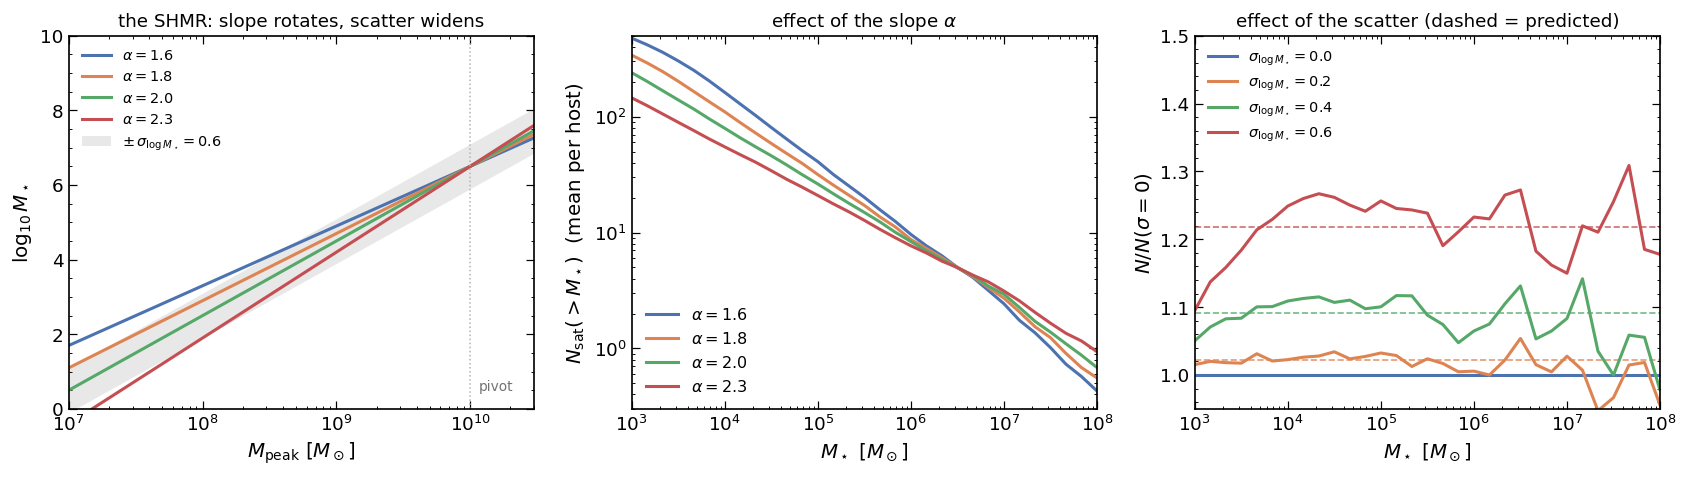

In [13]:
# Use the MEAN over hosts here, not the median: we are after the population
# abundance, and a median of small integer counts is quantized (2, 3, 4 ...),
# which turns a smooth ratio into a staircase.
ALPHAS = [1.6, 1.8, 2.0, 2.3]
SIGMAS = [0.0, 0.2, 0.4, 0.6]
beta = 0.91 / gh.FIDUCIAL_SHMR["alpha"]        # slope of N(>Mstar), from Section 0

def mean_smf(**shmr):
    """Mean N(>Mstar) per host for one set of SHMR parameters."""
    m = gh.populate_subhalos(sats_mw, shmr_params=dict(gh.FIDUCIAL_SHMR, **shmr),
                             rng=np.random.default_rng(42))
    return np.mean(st.per_host_counts(m, ms_edges, "mstar", host_ids=hid_mw), axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

# --- (a) the two knobs, on the relation itself
ax = axes[0]
for c, alpha in zip(pl.HOST_COLORS, ALPHAS):
    ax.plot(mgrid, gh.mean_stellar_mass(mgrid, alpha=alpha, logM0=10.0, logMstar0=6.5),
            color=c, label=rf"$\alpha={alpha}$")
mu_fid = gh.mean_stellar_mass(mgrid, **shmr_mean)
ax.fill_between(mgrid, mu_fid - max(SIGMAS), mu_fid + max(SIGMAS),
                color="0.5", alpha=0.18, lw=0,
                label=rf"$\pm\,\sigma_{{\log M_\star}}={max(SIGMAS)}$")
ax.axvline(1e10, color="0.7", ls=":", lw=1.0)
ax.text(1.15e10, 0.5, "pivot", color="0.45", fontsize=9)
ax.set(xscale="log", xlim=(1e7, 3e10), ylim=(0, 10),
       xlabel=r"$M_{\rm peak}\ [M_\odot]$", ylabel=r"$\log_{10}M_\star$")
ax.set_title("the SHMR: slope rotates, scatter widens", fontsize=12)
ax.legend(loc="upper left", fontsize=9.5)

# --- (b) slope -> stellar mass function
ax = axes[1]
for c, alpha in zip(pl.HOST_COLORS, ALPHAS):
    ax.plot(ms_edges, mean_smf(alpha=alpha), color=c, label=rf"$\alpha={alpha}$")
ax.set(xscale="log", yscale="log", xlim=(1e3, 1e8), ylim=(0.3, 5e2),
       xlabel=r"$M_\star\ [M_\odot]$",
       ylabel=r"$N_{\rm sat}(>M_\star)$  (mean per host)")
ax.set_title(r"effect of the slope $\alpha$", fontsize=12)
ax.legend(loc="lower left")

# --- (c) scatter -> ratio to zero scatter, against the Eddington prediction
ax = axes[2]
ref_cnt = None
for c, sig in zip(pl.HOST_COLORS, SIGMAS):
    cnt = mean_smf(sigma_logMstar=sig)
    if ref_cnt is None:
        ref_cnt = cnt
    ax.plot(ms_edges, cnt / np.where(ref_cnt > 0, ref_cnt, np.nan), color=c,
            label=rf"$\sigma_{{\log M_\star}}={sig}$")
    ax.axhline(np.exp(0.5 * (np.log(10) * beta * sig) ** 2),
               color=c, ls="--", lw=1.1, alpha=0.8)
ax.set(xscale="log", xlim=(1e3, 1e8), ylim=(0.95, 1.5),
       xlabel=r"$M_\star\ [M_\odot]$", ylabel=r"$N/N(\sigma=0)$")
ax.set_title("effect of the scatter (dashed = predicted)", fontsize=12)
ax.legend(loc="upper left", fontsize=9.5)
fig.tight_layout()

> ### Key lesson — Section 2
>
> Three knobs so far: $M_{50}$, $\alpha$ and $\sigma_{\log M_\star}$. $M_{50}$ acts almost
> entirely on the faintest dwarfs, while $\alpha$ and $\sigma_{\log M_\star}$ move the
> satellite stellar mass function in overlapping ways, which makes them partially degenerate.
>
> And we have applied no observational selection at all yet. Part 2 adds it, with knobs of its
> own.

**Try it.** Steepen the slope to $\alpha = 2.3$, then see how much of the fiducial stellar mass
function you can recover using the scatter alone. How close do you get, and at which end does
it fail? That mismatch is what makes the two parameters separable in principle, given data over
a wide enough mass range.